In [1]:
!pip install yfinance numpy pandas matplotlib scikit-learn

Fetching asset data from yfinance...


/tmp/ipykernel_455/3807474630.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2016-01-01", end="2026-01-01")
[*********************100%***********************]  1 of 1 completed


Data successfully loaded. Shape: (3653, 5)
Training data size: 2882 rows
Testing data size: 721 rows
Model training complete.


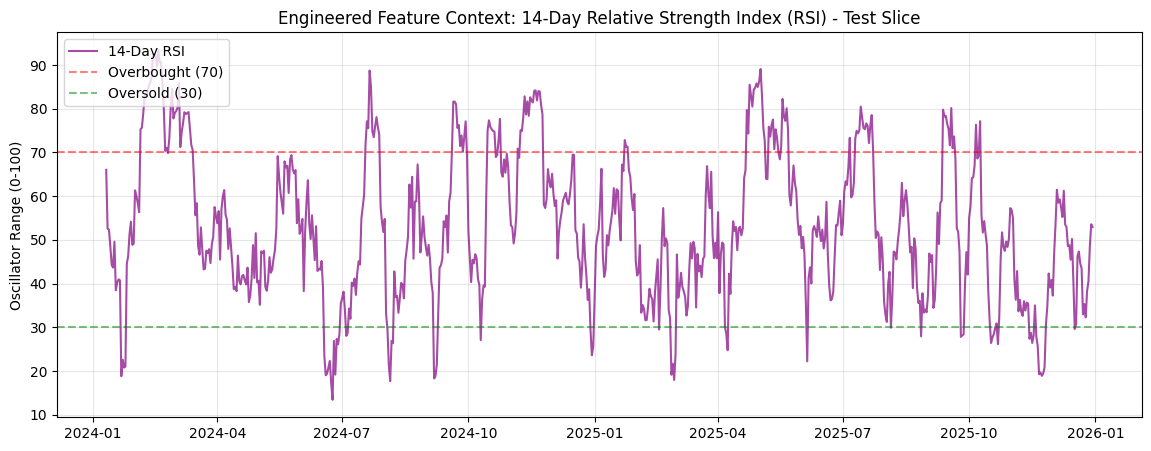

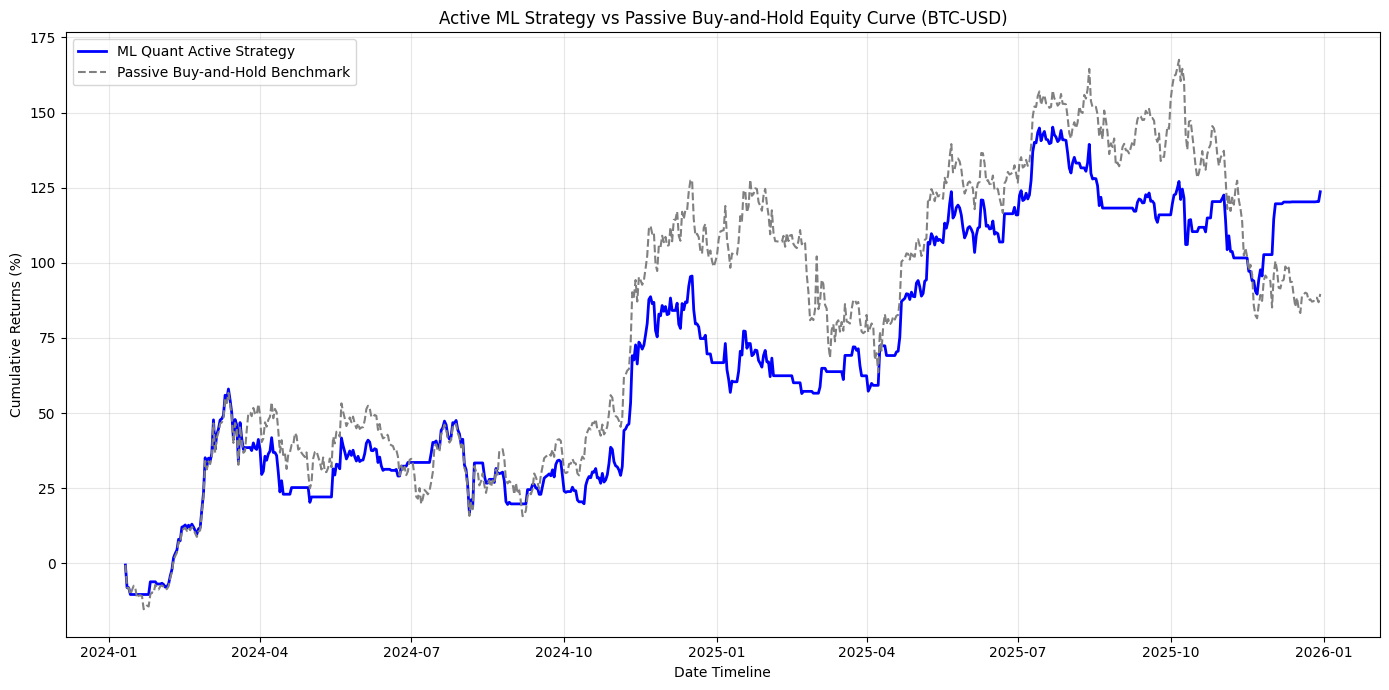


=== BACKTEST PERFORMANCE PERFORMANCE REPORT ===
Passive Buy-and-Hold Return : 89.65%
ML Active Strategy Return   : 123.64%
Alpha Generated             : 33.99%


In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# ==============================================================================
# STEP 1: DATA INGESTION & ENGINEERING
# ==============================================================================
print("Fetching asset data from yfinance...")
# Fetching 10 years of daily data for a highly volatile asset (BTC-USD)
ticker = "BTC-USD"
df = yf.download(ticker, start="2016-01-01", end="2026-01-01")

# Ensure single-dimensional column index if yfinance MultiIndex format occurs
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

print(f"Data successfully loaded. Shape: {df.shape}")

# --- Feature Engineering ---
# 1. Trend Momentum: SMA(10) / SMA(50) Ratio
sma10 = df['Close'].rolling(window=10).mean()
sma50 = df['Close'].rolling(window=50).mean()
df['Feature_SMA_Ratio'] = sma10 / sma50

# 2. Volatility Profile: Bollinger Band Bandwidth
rolling_mean_20 = df['Close'].rolling(window=20).mean()
rolling_std_20 = df['Close'].rolling(window=20).std()
upper_bb = rolling_mean_20 + (2 * rolling_std_20)
lower_bb = rolling_mean_20 - (2 * rolling_std_20)
df['Feature_BB_Bandwidth'] = (upper_bb - lower_bb) / rolling_mean_20

# 3. Market Velocity: Relative Strength Index (RSI - 14 Days)
delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / (loss + 1e-9)  # Avoid division by zero
df['Feature_RSI'] = 100 - (100 / (1 + rs))

# 4. Volume Dynamics: Volume / Rolling Average Volume(15) Ratio
rolling_vol_15 = df['Volume'].rolling(window=15).mean()
df['Feature_Volume_Ratio'] = df['Volume'] / rolling_vol_15

# 5. Target Definition: Next-Day Forward Return
# (Close_t+1 - Close_t) / Close_t -> Shifted backward by 1 day to represent tomorrow's return
df['Actual_Return'] = df['Close'].pct_change()
df['Target_Forward_Return'] = df['Actual_Return'].shift(-1)

# Clean out non-stationary artifacts and rolling lookback NaN windows
df.dropna(inplace=True)

# Define feature columns and target matrix
feature_cols = ['Feature_SMA_Ratio', 'Feature_BB_Bandwidth', 'Feature_RSI', 'Feature_Feature_Volume_Ratio']
# Mapping feature names accurately to columns
df.rename(columns={'Feature_Volume_Ratio': 'Feature_Volume_Ratio'}, inplace=True)
feature_cols = ['Feature_SMA_Ratio', 'Feature_BB_Bandwidth', 'Feature_RSI', 'Feature_Volume_Ratio']

X = df[feature_cols]
y = df['Target_Forward_Return']

# ==============================================================================
# STEP 2: CHRONOLOGICAL TIME-SERIES SPLIT (80% Train / 20% Test)
# ==============================================================================
split_idx = int(len(df) * 0.80)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training data size: {X_train.shape[0]} rows")
print(f"Testing data size: {X_test.shape[0]} rows")

# ==============================================================================
# STEP 3: MODEL SETUP & COMPLEXITY BOUNDARIES
# ==============================================================================
# Setting strict structural boundaries to prevent noise memorization/overfitting
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    min_samples_leaf=10,
    random_state=42
)
model.fit(X_train, y_train)
print("Model training complete.")

# ==============================================================================
# STEP 4: VECTORIZED BACKTESTING FRAMEWORK
# ==============================================================================
# Generate out-of-sample directional returns predictions
test_df = df.iloc[split_idx:].copy()
test_df['Predicted_Return'] = model.predict(X_test)

# Map predictions into position signals (+1 for Long, 0 for Cash/Short)
test_df['Signal'] = np.where(test_df['Predicted_Return'] > 0, 1, 0)

# Critical Execution Step: Shift signals by 1 day to completely prevent lookahead bias
# This ensures today's return is multiplied by yesterday's generated end-of-day prediction signal
test_df['Executed_Signal'] = test_df['Signal'].shift(1)
test_df.dropna(inplace=True)

# Compute Strategy vs Passive Benchmark Returns
test_df['Passive_Benchmark_Returns'] = test_df['Actual_Return']
test_df['Strategy_Returns'] = test_df['Executed_Signal'] * test_df['Passive_Benchmark_Returns']

# Compute Cumulative Returns Performance
test_df['Cumulative_Benchmark'] = (1 + test_df['Passive_Benchmark_Returns']).cumprod() - 1
test_df['Cumulative_Strategy'] = (1 + test_df['Strategy_Returns']).cumprod() - 1

# ==============================================================================
# VISUAL PLOTS AND PERFORMANCE METRICS
# ==============================================================================
# Plot 1: Technical Indicators Overview (RSI Highlight)
plt.figure(figsize=(14, 5))
plt.plot(test_df.index, test_df['Feature_RSI'], label='14-Day RSI', color='purple', alpha=0.7)
plt.axhline(70, color='red', linestyle='--', alpha=0.5, label='Overbought (70)')
plt.axhline(30, color='green', linestyle='--', alpha=0.5, label='Oversold (30)')
plt.title(f"Engineered Feature Context: 14-Day Relative Strength Index (RSI) - Test Slice")
plt.ylabel("Oscillator Range (0-100)")
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

# Plot 2: Final Line Chart Comparing Equity Curves
plt.figure(figsize=(14, 7))
plt.plot(test_df.index, test_df['Cumulative_Strategy'] * 100, label='ML Quant Active Strategy', color='blue', linewidth=2)
plt.plot(test_df.index, test_df['Cumulative_Benchmark'] * 100, label='Passive Buy-and-Hold Benchmark', color='gray', linestyle='--', linewidth=1.5)
plt.title(f"Active ML Strategy vs Passive Buy-and-Hold Equity Curve ({ticker})")
plt.xlabel("Date Timeline")
plt.ylabel("Cumulative Returns (%)")
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Final Metrics Output
final_strat = test_df['Cumulative_Strategy'].iloc[-1] * 100
final_bench = test_df['Cumulative_Benchmark'].iloc[-1] * 100
print("\n=== BACKTEST PERFORMANCE PERFORMANCE REPORT ===")
print(f"Passive Buy-and-Hold Return : {final_bench:.2f}%")
print(f"ML Active Strategy Return   : {final_strat:.2f}%")
print(f"Alpha Generated             : {(final_strat - final_bench):.2f}%")